# **HOMEWORK 2: Stochastic Gradient Descent**

=== Exercise 1: GD vs SGD ===
GD   final loss=0.049152  Theta=[1.41084053 1.23610054]
SGD  batch=1     final loss=0.000097  Theta=[0.99989563 1.99955978]
SGD  batch=10    final loss=0.000098  Theta=[1.00283113 1.99818875]
SGD  batch=50    final loss=0.004615  Theta=[1.12465268 1.76612189]
SGD  batch=200   final loss=0.049152  Theta=[1.41084053 1.23610054]


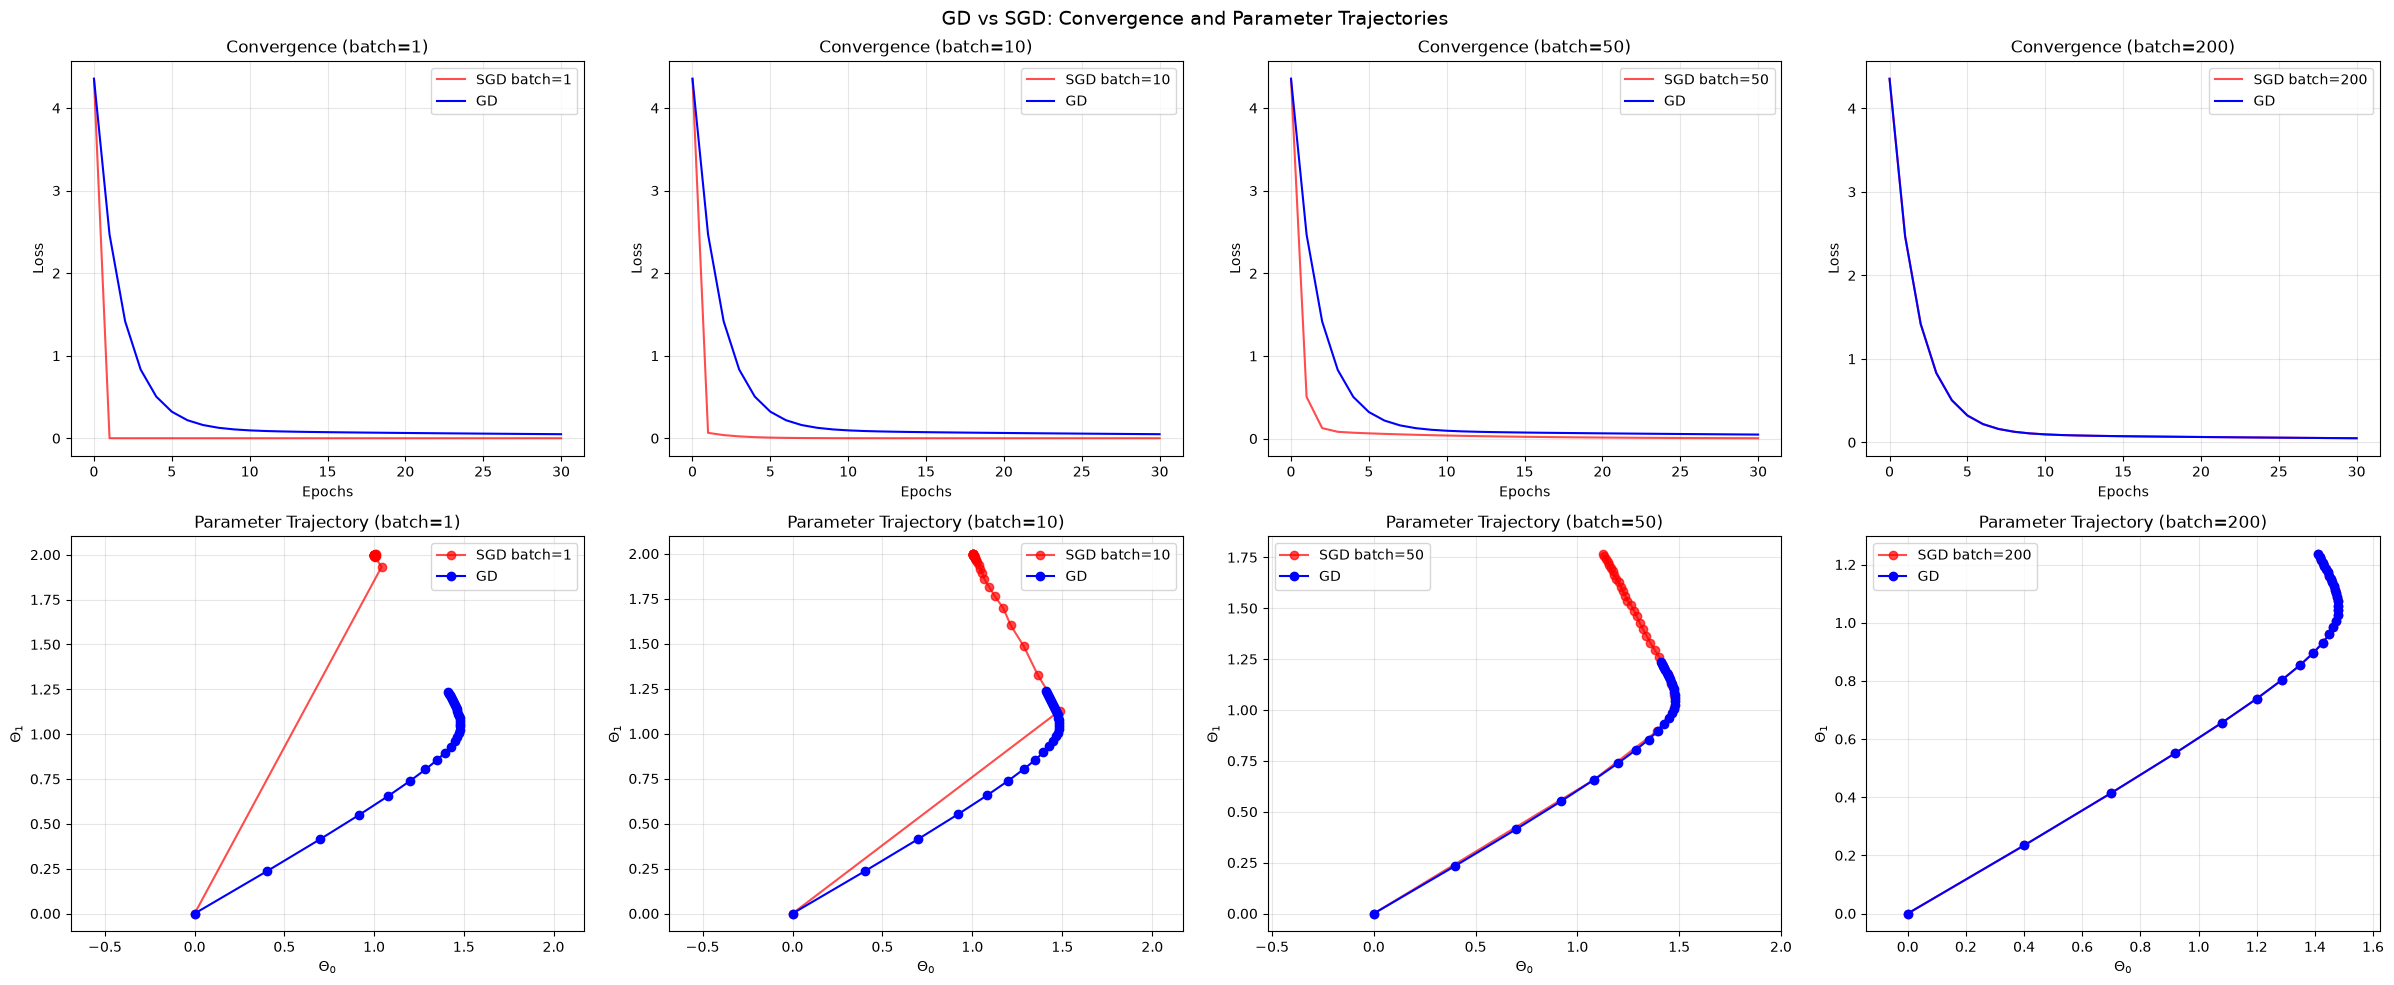

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: SGD vs GD on a simple 1D Regression Problem
N = 200
X = (np.arange(1,N+1)/N).reshape(-1,1)
eps = np.random.normal(0,0.01,size=X.shape)
Y = (2 * X + 1 + eps).reshape(-1,1)
X = np.hstack([np.ones((N, 1)), X])

def l(Theta, X, Y):
    residuals = X @ Theta - Y
    return (residuals**2).mean()

def grad_l(Theta, X, Y):
    return (2/X.shape[0]) * X.T @ (X @ Theta - Y)

def GD(l, grad_l, Theta0, X, Y, lr=0.1, epochs=30):
    thetas = [Theta0.copy()]
    theta = Theta0.copy()
    losses = [l(theta, X, Y)]
    for k in range(epochs):
        theta = theta - lr * grad_l(theta, X, Y)
        thetas.append(theta.copy())
        losses.append(l(theta,X,Y))
    return np.array(thetas), losses

def SGD(l, grad_l, Theta0, X, Y, batch_size=32, lr=0.1, epochs=30):
    losses = [l(Theta0, X, Y)]
    Theta = Theta0.copy()
    thetas = [Theta.copy()]
    N = X.shape[0]
    for epoch in range(epochs):
        indices = np.random.permutation(N)
        for start in range(0, N, batch_size):
            batch_idx = indices[start : start+batch_size]
            Xb = X[batch_idx]
            Yb = Y[batch_idx]
            g = grad_l(Theta, Xb, Yb)
            Theta = Theta - lr * g
        losses.append(l(Theta, X, Y))
        thetas.append(Theta.copy())
    return np.array(thetas), losses

batch_sizes = [1, 10, 50, N]
Theta_gd, loss_gd = GD(l, grad_l, np.zeros((X.shape[1], 1)), X, Y)
sgd_results = {}
for b in batch_sizes:
    Thetas_sgd, loss_sgd = SGD(l, grad_l, np.zeros((X.shape[1], 1)), X, Y, batch_size=b)
    sgd_results[b] = {"thetas": np.array(Thetas_sgd), "losses": np.array(loss_sgd)}

print("=== Exercise 1: GD vs SGD ===")
print(f"GD   final loss={loss_gd[-1]:.6f}  Theta={Theta_gd[-1].ravel()}")
for b in batch_sizes:
    losses = sgd_results[b]["losses"]
    theta_final = sgd_results[b]["thetas"][-1].ravel()
    print(f"SGD  batch={b:<4}  final loss={losses[-1]:.6f}  Theta={theta_final}")

# first row loss, second row parameter trajectory
fig, axes = plt.subplots(2, len(batch_sizes), figsize=(6 * len(batch_sizes), 10))
fig.suptitle("GD vs SGD: Convergence and Parameter Trajectories", fontsize=14)

for col, b in enumerate(batch_sizes):
    losses = sgd_results[b]["losses"]
    thetas = sgd_results[b]["thetas"]


    ax_loss = axes[0, col]
    ax_loss.plot(losses, label=f"SGD batch={b}", alpha=0.7, color="red")
    ax_loss.plot(loss_gd, label="GD", color="blue")
    ax_loss.set_xlabel("Epochs")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"Convergence (batch={b})")
    ax_loss.grid(alpha=0.3)
    ax_loss.legend()

    ax_traj = axes[1, col]
    ax_traj.plot(thetas[:,0], thetas[:,1], "o-", label=f"SGD batch={b}", alpha=0.7, color="red")
    ax_traj.plot(Theta_gd[:,0], Theta_gd[:,1], "o-", label="GD", color="blue")
    ax_traj.set_xlabel(r"$\Theta_0$")
    ax_traj.set_ylabel(r"$\Theta_1$")
    ax_traj.set_title(f"Parameter Trajectory (batch={b})")
    ax_traj.grid(alpha=0.3)
    ax_traj.legend()
    ax_traj.axis("equal")

plt.tight_layout()
plt.show()


=== Exercise 2: Gradient Variance vs Batch Size ===
  batch=1     Var(g)=0.044278
  batch=5     Var(g)=0.010956
  batch=20    Var(g)=0.001996
  batch=200   Var(g)=0.000000


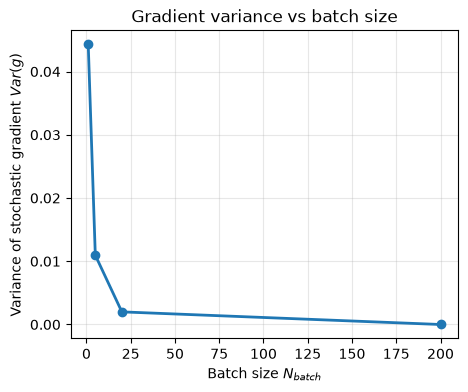

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 2: Variance of the Stochastic Gradient
N_batch = [1, 5, 20, N]
Theta_fixed = np.array([[1.0], [2.0]])
K = 100

variances = {}

def grad_l_batch(Theta, X, Y, batch_idx):
    Xb = X[batch_idx]
    Yb = Y[batch_idx]
    return (2 / len(batch_idx)) * Xb.T @ (Xb @ Theta - Yb)

for b in N_batch:
    gradients = np.zeros((K, 2))
    for k in range(K):
        batch_idx = np.random.choice(N, size=b, replace=False)
        gk = grad_l_batch(Theta_fixed, X, Y, batch_idx)
        gradients[k, :] = gk.ravel()
        
    g_bar = gradients.mean(axis=0)
    diffs = gradients - g_bar
    var_g = np.sum(np.linalg.norm(diffs, axis=1)**2).mean()
    variances[b] = var_g

print("=== Exercise 2: Gradient Variance vs Batch Size ===")
for b, v in sorted(variances.items()):
    print(f"  batch={b:<4}  Var(g)={v:.6f}")

batch_sizes = sorted(variances.keys())
var_values  = [variances[b] for b in batch_sizes]
plt.figure(figsize=(5,4))
plt.plot(batch_sizes, var_values, "o-", linewidth=2)
plt.xlabel("Batch size $N_{batch}$")
plt.ylabel(r"Variance of stochastic gradient $Var(g)$")
plt.title("Gradient variance vs batch size")
plt.grid(alpha=0.3)
plt.show()


=== Exercise 3: SGD in 2D — final loss and position ===
  sigma=0.99  lr=1e-02  final_L=0.0000  Theta=[1. 1.]
  sigma=0.99  lr=1e-03  final_L=0.0001  Theta=[1.004  1.0086]
  sigma=0.99  lr=1e-04  final_L=0.2592  Theta=[1.2211 1.5335]
  sigma=0.99  lr=1e-02  final_L=0.0000  Theta=[0.9967 0.993 ]
  sigma=0.99  lr=1e-03  final_L=0.0000  Theta=[1.0023 1.0056]
  sigma=0.99  lr=1e-04  final_L=0.2593  Theta=[1.2211 1.5337]
  sigma=0.99  lr=1e-02  final_L=0.0039  Theta=[1.0016 0.9835]
  sigma=0.99  lr=1e-03  final_L=0.0000  Theta=[0.9978 0.9965]
  sigma=0.99  lr=1e-04  final_L=0.2601  Theta=[1.2212 1.5345]
  sigma=0.99  lr=1e-02  final_L=0.0016  Theta=[1.0041 0.9959]
  sigma=0.99  lr=1e-03  final_L=0.0003  Theta=[1.0074 1.0179]
  sigma=0.99  lr=1e-04  final_L=0.2620  Theta=[1.2221 1.5364]


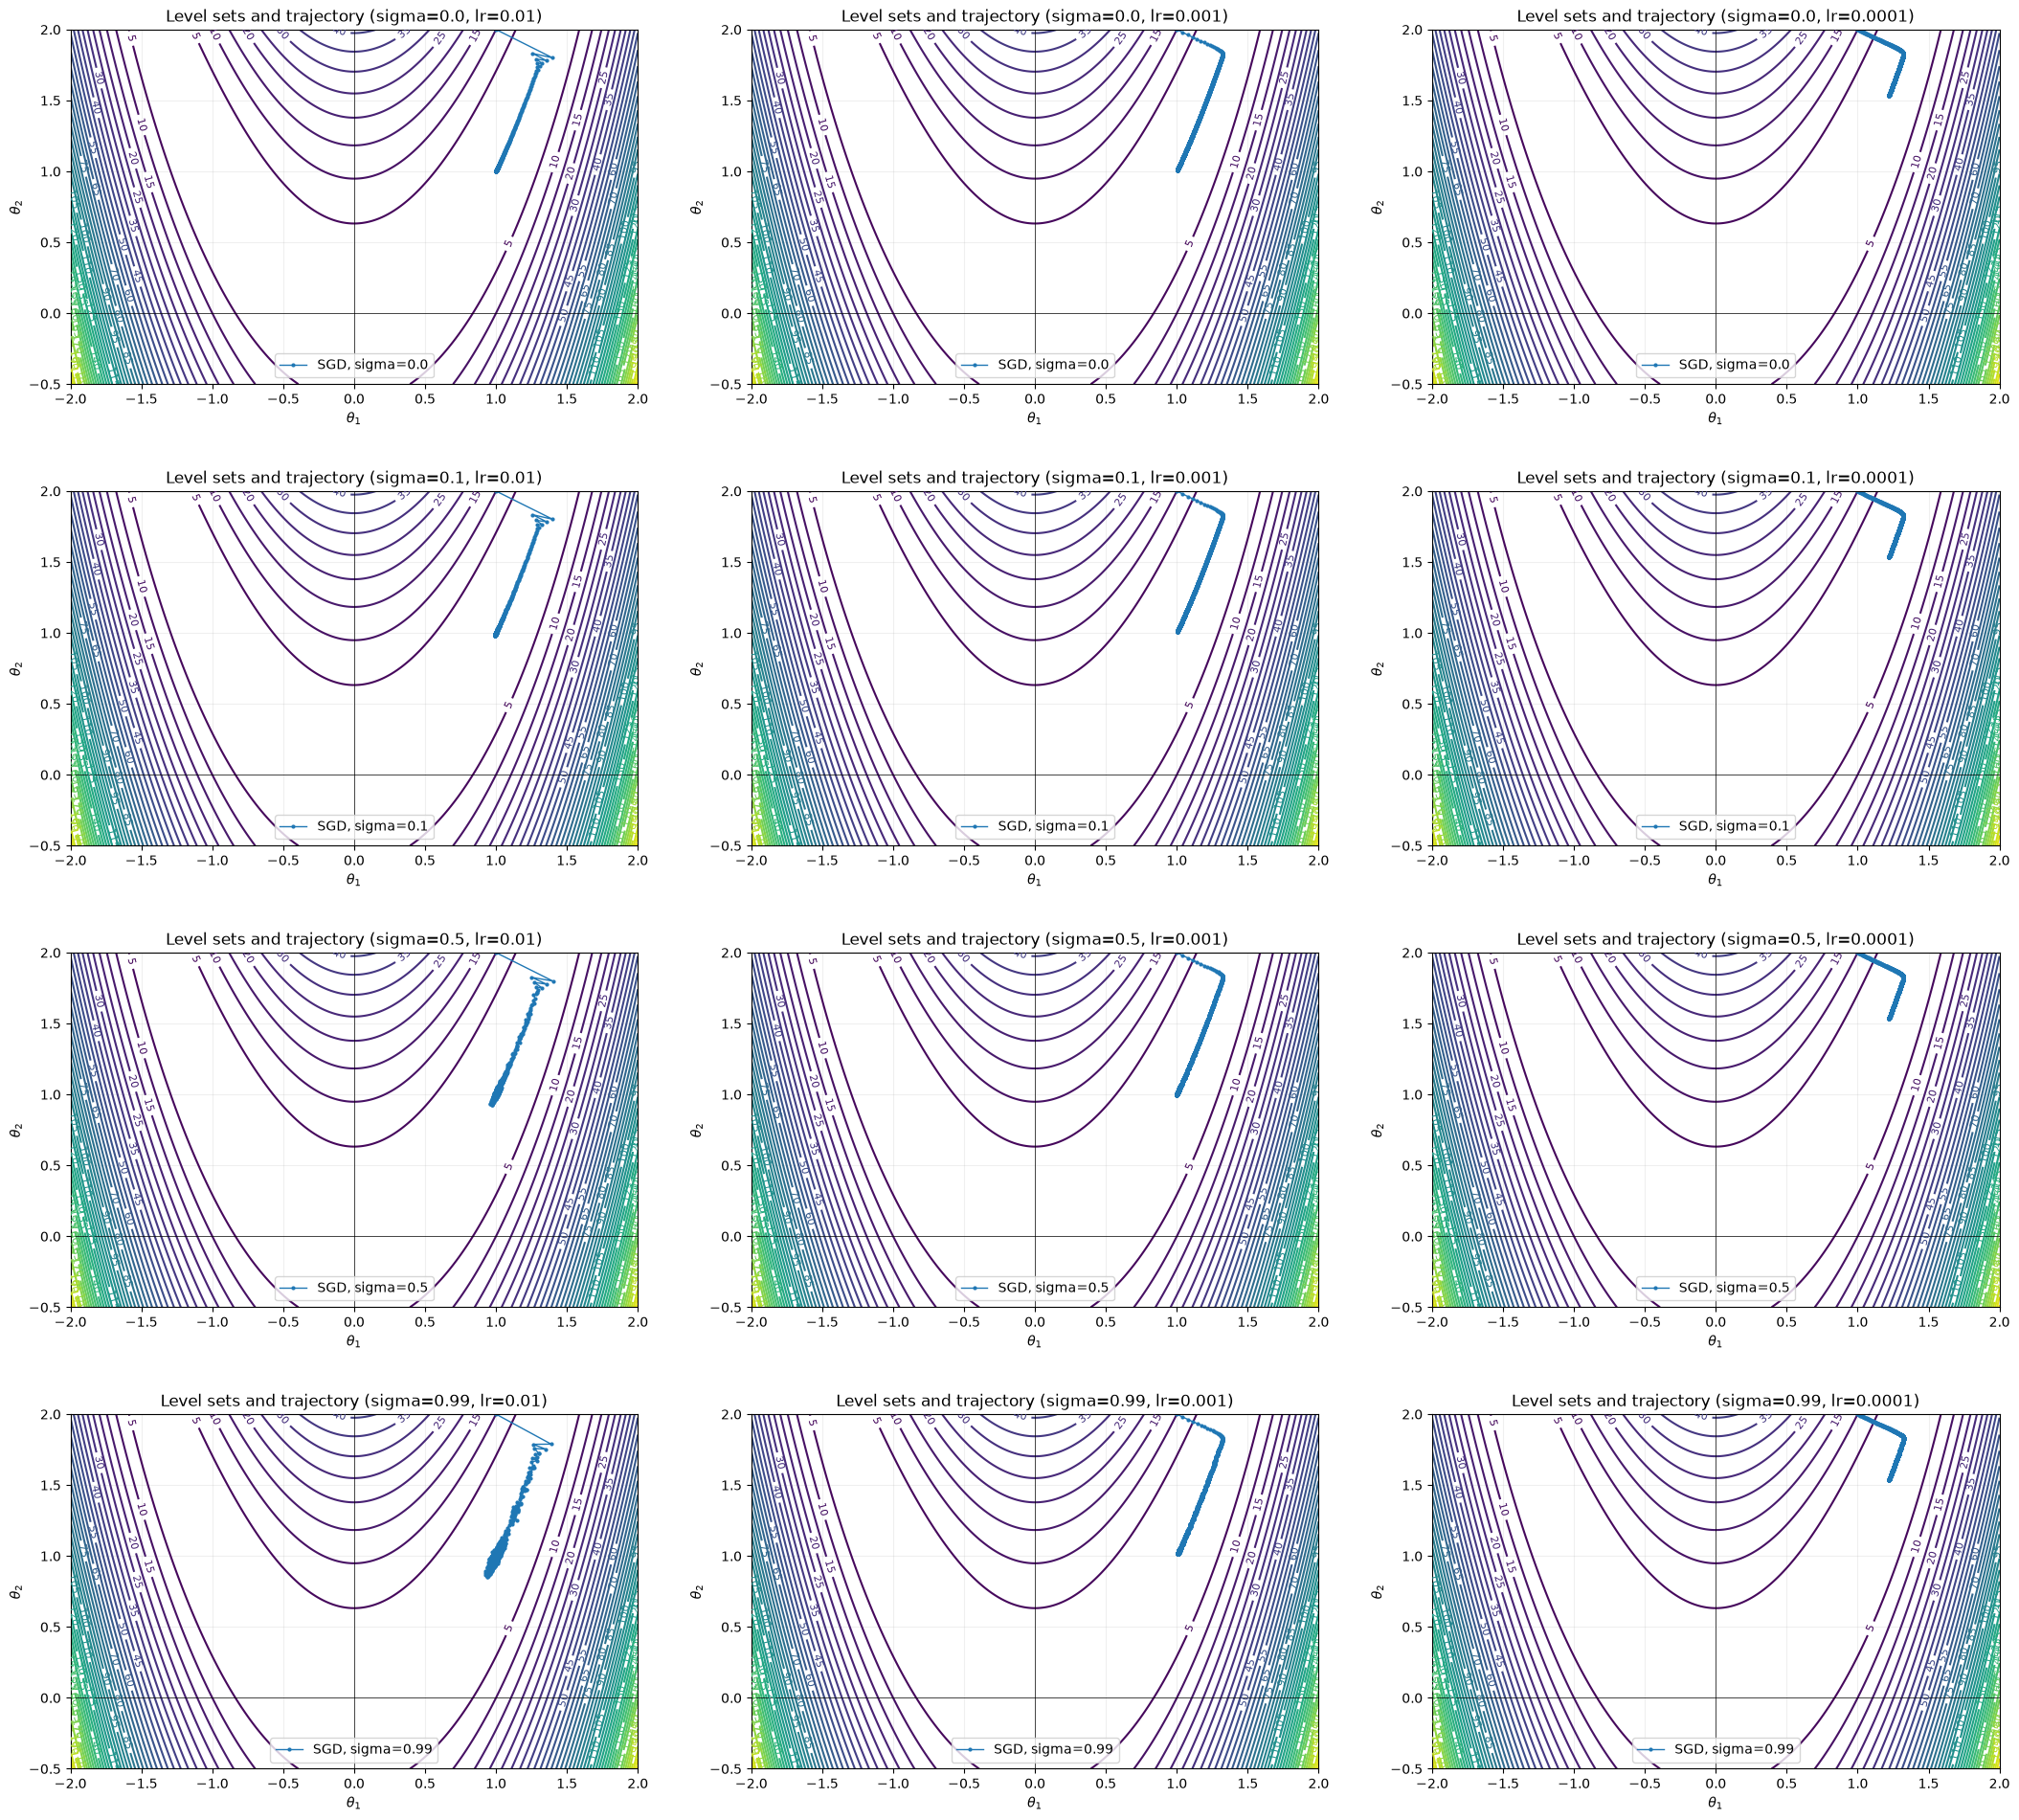

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 3: SGD in 2D
def l(Theta):
    return (Theta[0]**2 - 1)**2 + 10*(Theta[1] - Theta[0]**2)**2

def grad_l(Theta):
    g1 = 4*(Theta[0]**3 - Theta[0]) + 40*(Theta[0]**3 - Theta[1]*Theta[0])
    g2 = 20*(Theta[1] - Theta[0]**2)
    return np.array([g1, g2])

def SGD_noise(l, grad_l, Theta0, sigma, batch_size=32, lr=1e-2, epochs=3000):
    losses = [l(Theta0)]
    Theta = Theta0.copy()
    thetas = [Theta.copy()]
    for epoch in range(epochs):
        eps = np.random.normal(0, sigma, size=2)
        g_real = grad_l(Theta)
        gk  = g_real + eps
        Theta = Theta - lr*gk
        losses.append(l(Theta))
        thetas.append(Theta.copy())
    return np.array(thetas), np.array(losses)

sigmas = [0.0, 0.1, 0.5, 0.99]
Theta0 = np.array([1, 2])
step_sizes = [1e-2, 1e-3, 1e-4]
results    = {}
for sigma in sigmas:
    results[sigma] = {}
    for step in step_sizes:
        thetas, losses = SGD_noise(l=l, grad_l=grad_l, Theta0=Theta0, sigma=sigma, lr=step)
        results[sigma][step] = {"thetas": thetas, "losses": losses}

print("=== Exercise 3: SGD in 2D — final loss and position ===")
for sigma in sigmas:
    for step in step_sizes:
        r    = results[sigma][step]
        path = r["thetas"]
        fin  = path[-1]
        print(f"  sigma={s:.2f}  lr={step:.0e}  final_L={r['losses'][-1]:.4f}  Theta={fin.round(4)}")

def levelsets_l(xlim=(-2, 2), ylim=(-0.5, 2), ngrid=400, ncontours=50, title=None):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = l([X, Y])
    cs = plt.contour(X, Y, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.grid(alpha=0.2)

fig, axes = plt.subplots(4, 3, figsize=(26, 24))
for idx, sigma in enumerate(sigmas):
    for idx2, step_size in enumerate(step_sizes):
        ax = axes[idx, idx2]
        plt.sca(ax)
        levelsets_l(title=f"Level sets and trajectory (sigma={sigma}, lr={step_size})")
        thetas = results[sigma][step_size]["thetas"]
        plt.plot(thetas[:,0], thetas[:,1], "o-", markersize=2,
                linewidth=1, label=f"SGD, sigma={sigma}")
        plt.legend()
plt.show()


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dataset size: 1338 samples, 4 features (bias + 3 predictors)

=== Exercise 4: Final Results ===
GD: Theta=[0.     0.2784 0.1672 0.054 ]  loss=0.8799  grad_norm=0.0000
SGD  batch=1         Theta=[0.0733 0.3914 0.1069 0.0638]  loss=0.9003  grad_norm=0.2775
SGD  batch=10        Theta=[0.005  0.3042 0.2036 0.0578]  loss=0.8822  grad_norm=0.0999
SGD  batch=50        Theta=[-0.0054  0.2771  0.164   0.0535]  loss=0.8799  grad_norm=0.0132


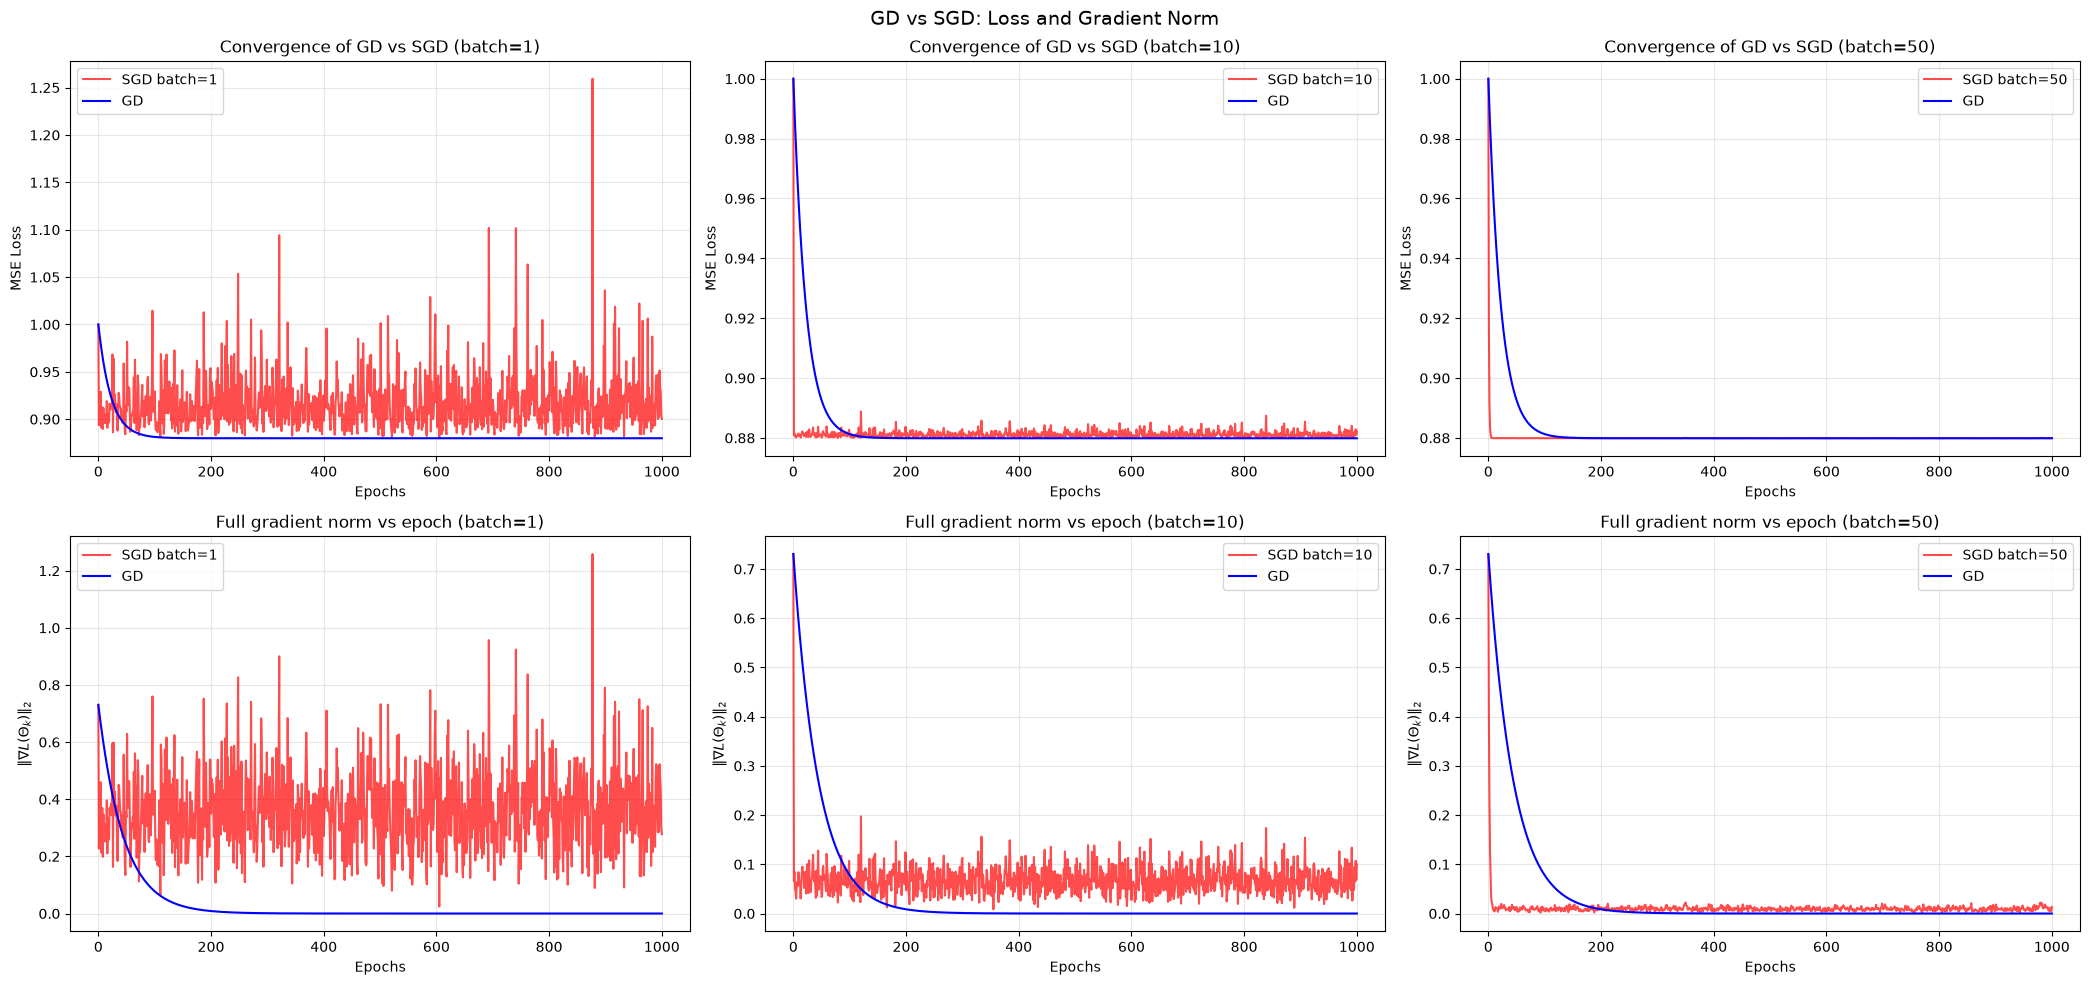

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Exercise 4: ML project with SGD on insurance dataset
url = "insurance.csv"
train_data = pd.read_csv(url)
print(train_data.head())

features = ["age", "bmi", "children"]
X = train_data[features].values
Y = train_data["charges"].values.reshape(-1, 1)

X = (X - X.mean(axis=0)) / X.std(axis=0)
Y = (Y - Y.mean(axis=0)) / Y.std(axis=0)

bias_column = np.ones((X.shape[0], 1))
X = np.hstack([bias_column, X])
N, d = X.shape
print(f"Dataset size: {N} samples, {d} features (bias + {d-1} predictors)")

def l(Theta, X, Y):
    return np.mean(np.square(X @ Theta - Y))

def grad_l(Theta, X, Y):
    return 2 * X.T @ (X @ Theta - Y) / X.shape[0]

def GD(l, grad_l, Theta0, X, Y, lr=1e-2, epochs=1000):
    thetas = [Theta0.copy()]
    theta = Theta0.copy()
    losses = [l(theta, X, Y)]
    grad_norms = [np.linalg.norm(grad_l(theta, X, Y))]
    for k in range(epochs):
        theta = theta - lr * grad_l(theta, X, Y)
        thetas.append(theta.copy())
        losses.append(l(theta, X, Y))
        grad_norms.append(np.linalg.norm(grad_l(theta, X, Y)))
    return np.array(thetas), np.array(losses), np.array(grad_norms)

def SGD(l, grad_l, Theta0, X, Y, batch_size, lr=1e-2, epochs=1000):
    losses = [l(Theta0, X, Y)]
    Theta = Theta0.copy()
    thetas = [Theta.copy()]
    grad_norms = [np.linalg.norm(grad_l(Theta, X, Y))]
    N = X.shape[0]
    for epoch in range(epochs):
        indices = np.random.permutation(N)
        for start in range(0, N, batch_size):
            batch_idx = indices[start : start+batch_size]
            Xb = X[batch_idx]
            Yb = Y[batch_idx]
            g = grad_l(Theta, Xb, Yb)
            Theta = Theta - lr * g
        losses.append(l(Theta, X, Y))
        thetas.append(Theta.copy())
        grad_norms.append(np.linalg.norm(grad_l(Theta, X, Y)))
    return np.array(thetas), np.array(losses), np.array(grad_norms)

batch_sizes = [1, 10, 50]
Theta_gd, loss_gd, grad_norms_gd = GD(l, grad_l, np.zeros((d, 1)), X, Y)
sgd_results = {}
for b in batch_sizes:
    Thetas_sgd, loss_sgd, grad_norms_sgd = SGD(l, grad_l, np.zeros((d, 1)), X, Y, batch_size=b)
    sgd_results[b] = {"thetas": Thetas_sgd, "losses": loss_sgd, "grad_norms": grad_norms_sgd}

print("\n=== Exercise 4: Final Results ===")

print(f"GD: Theta={Theta_gd[-1].ravel().round(4)}  loss={loss_gd[-1]:.4f}  grad_norm={grad_norms_gd[-1]:.4f}")
for b in batch_sizes:
    r = sgd_results[b]
    print(f"SGD  batch={b:<4}      Theta={r['thetas'][-1].ravel().round(4)}  loss={r['losses'][-1]:.4f}  grad_norm={r['grad_norms'][-1]:.4f}")

fig, axes = plt.subplots(2, len(batch_sizes), figsize=(7 * len(batch_sizes), 10))
fig.suptitle("GD vs SGD: Loss and Gradient Norm", fontsize=14)

for col, b in enumerate(batch_sizes):
    losses_b     = sgd_results[b]["losses"]
    grad_norms_b = sgd_results[b]["grad_norms"]

    axes[0, col].plot(losses_b, label=f"SGD batch={b}", alpha=0.7, color="red")
    axes[0, col].plot(loss_gd,  label="GD",             color="blue")
    axes[0, col].set_xlabel("Epochs")
    axes[0, col].set_ylabel("MSE Loss")
    axes[0, col].set_title(f"Convergence of GD vs SGD (batch={b})")
    axes[0, col].grid(alpha=0.3)
    axes[0, col].legend()

    axes[1, col].plot(grad_norms_b, label=f"SGD batch={b}", alpha=0.7, color="red")
    axes[1, col].plot(grad_norms_gd, label="GD",             color="blue")
    axes[1, col].set_xlabel("Epochs")
    axes[1, col].set_ylabel(r"$\|\nabla L(\Theta_k)\|_2$")
    axes[1, col].set_title(f"Full gradient norm vs epoch (batch={b})")
    axes[1, col].grid(alpha=0.3)
    axes[1, col].legend()

plt.tight_layout()
plt.show()
